In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy
import math

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
#from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active
from common.optimise_v3 import NetLineStepProcessor
#from common.dropout_manual import DropoutManual

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 64 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def init_weights_copy(net, params):
    net.init_linear_zeros(net.conv1, True)
    net.init_linear_zeros(net.conv2, True)
    net.init_linear_zeros(net.conv3, True)
    net.init_linear_zeros(net.conv4, True)
    net.init_linear_zeros(net.linear5, True)
    net.init_linear_zeros(net.linear6, True)
    with torch.no_grad():
        net.conv1.weight += torch.from_numpy(params['0.weight']).to(DEVICE)
        net.conv1.bias += torch.from_numpy(params['0.bias']).to(DEVICE)
        net.conv2.weight += torch.from_numpy(params['2.weight']).to(DEVICE)
        net.conv2.bias += torch.from_numpy(params['2.bias']).to(DEVICE)
        net.conv3.weight += torch.from_numpy(params['6.weight']).to(DEVICE)
        net.conv3.bias += torch.from_numpy(params['6.bias']).to(DEVICE)
        net.conv4.weight += torch.from_numpy(params['8.weight']).to(DEVICE)
        net.conv4.bias += torch.from_numpy(params['8.bias']).to(DEVICE)
        net.linear5.weight += torch.from_numpy(params['13.weight']).to(DEVICE)
        net.linear5.bias += torch.from_numpy(params['13.bias']).to(DEVICE)
        net.linear6.weight += torch.from_numpy(params['16.weight']).to(DEVICE)
        net.linear6.bias += torch.from_numpy(params['16.bias']).to(DEVICE)

def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    #axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    #axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model(dropout_const = 1.0):
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5*dropout_const),
        nn.Linear(256, 10)
    )

    return model

In [8]:
#HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

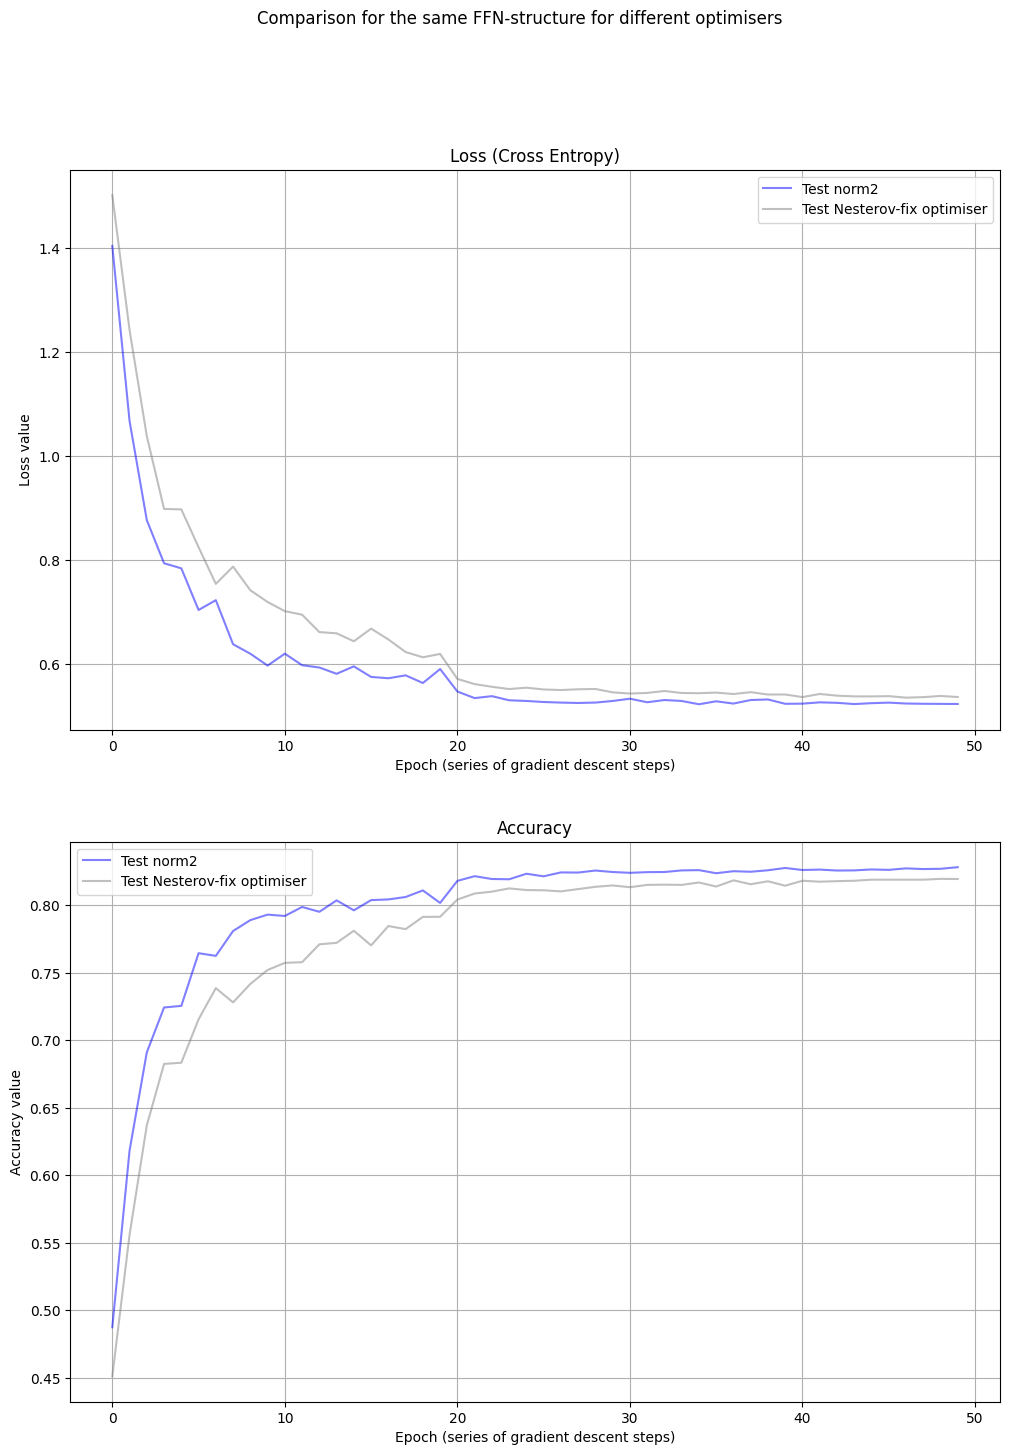

accuracy:
norm2=[0.4875597133757962, 0.6183320063694268, 0.6910828025477707, 0.7243232484076433, 0.7255175159235668, 0.76453025477707, 0.7625398089171974, 0.7809514331210191, 0.7890127388535032, 0.793093152866242, 0.7920979299363057, 0.798765923566879, 0.7951831210191083, 0.8036425159235668, 0.7962778662420382, 0.8038415605095541, 0.8043391719745223, 0.8061305732484076, 0.8110071656050956, 0.8017515923566879, 0.8180732484076433, 0.8215565286624203, 0.8194665605095541, 0.8192675159235668, 0.8233479299363057, 0.8214570063694268, 0.824343152866242, 0.8242436305732485, 0.8257364649681529, 0.8246417197452229, 0.8240445859872612, 0.8245421974522293, 0.8246417197452229, 0.8258359872611465, 0.8260350318471338, 0.8237460191082803, 0.8252388535031847, 0.8248407643312102, 0.8259355095541401, 0.8276273885350318, 0.8261345541401274, 0.8264331210191083, 0.8257364649681529, 0.8258359872611465, 0.8265326433121019, 0.826234076433121, 0.8273288216560509, 0.8268312101910829, 0.82703025477707, 0.828224522

In [9]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)
params = {k: v.detach().cpu().numpy().copy() for k, v in testOptfix.named_parameters()}

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

do_dropout, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.00001:
        do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch

    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.05
    stepProcessor.eta_max = 100*lr
    stepProcessor.eta_min = 0.1* lr if not do_dropout else lr
    stepProcessor.eta0 = 0.000_000_5
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0
    
    stepProcessor.meta.check_dropout=do_dropout
    testNorm2S.train(do_dropout)
    step_params = {"estimation_type": 'analytic-norm2'} if not do_dropout else {"check_additional": False, 'check_armiho': False}

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train(do_dropout)

    train_eta2raw_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_eta2raw_meter.update(step_result.eta_raw)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)

        logging.info("####Step with Optim-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw'].append(train_eta2raw_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    # testing loop
    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX)
    print("accuracy\norm2={}, \naccuracy Nesterov-fix={}; switch={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], epoch_switch))


In [10]:
HISTORY_NORM2['train_armiho']


[0.8561840953061562,
 0.8031287783603696,
 0.7691386317659658,
 0.7356437122786134,
 0.7023958094422201,
 0.6691519478813391,
 0.6407533763462026,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [11]:
HISTORY_NORM2['train_wolf']

[0.6669661330343144,
 0.6645742333952641,
 0.6241714197998269,
 0.5839071095272671,
 0.5453891377819268,
 0.5087057075933812,
 0.47563635134431,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [12]:
HISTORY_NORM2['train_eta']

[0.016271803575800523,
 0.02514577400079386,
 0.026680862562954655,
 0.027002887876315412,
 0.027004121218606264,
 0.02664473266727401,
 0.026161535451622992,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.00010000000000000155,
 0.00010000000000000155,
 0.000100000

In [13]:
HISTORY_NORM2['train_eta_raw']

[0.016263570978231254,
 0.02514577400079386,
 0.026680862562954655,
 0.027002887876315412,
 0.027004121218606264,
 0.02664473266727401,
 0.026161535451622992,
 1.2592426072992175e-07,
 1.2463728905848918e-07,
 1.289419236353649e-07,
 1.257696841848541e-07,
 1.2648503407786536e-07,
 1.2708635678911445e-07,
 1.2699007957391043e-07,
 1.306023460055837e-07,
 1.2963995156262226e-07,
 1.2264161907358833e-07,
 1.2746597673996243e-07,
 1.2949741926730946e-07,
 1.2128606003774042e-07,
 1.2373472534758547e-07,
 1.2354884034093634e-07,
 1.2538150714797686e-07,
 1.2869392265166915e-07,
 1.2927205851970855e-07,
 1.2623330075431343e-07,
 1.196848861009019e-07,
 1.2999283775969973e-07,
 1.229732063416775e-07,
 1.2441014072758713e-07,
 1.2374929382129287e-07,
 1.2802608993645804e-07,
 1.2863623044937067e-07,
 1.316773092861931e-07,
 1.23279559119502e-07,
 1.3101922619702433e-07,
 1.254480934212229e-07,
 1.2183595129185985e-07,
 1.2277839675942655e-07,
 1.2677581886985932e-07,
 1.2456828448122708e-07,


In [14]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.4875597133757962, 0.6183320063694268, 0.6910828025477707, 0.7243232484076433, 0.7255175159235668, 0.76453025477707, 0.7625398089171974, 0.7809514331210191, 0.7890127388535032, 0.793093152866242, 0.7920979299363057, 0.798765923566879, 0.7951831210191083, 0.8036425159235668, 0.7962778662420382, 0.8038415605095541, 0.8043391719745223, 0.8061305732484076, 0.8110071656050956, 0.8017515923566879, 0.8180732484076433, 0.8215565286624203, 0.8194665605095541, 0.8192675159235668, 0.8233479299363057, 0.8214570063694268, 0.824343152866242, 0.8242436305732485, 0.8257364649681529, 0.8246417197452229, 0.8240445859872612, 0.8245421974522293, 0.8246417197452229, 0.8258359872611465, 0.8260350318471338, 0.8237460191082803, 0.8252388535031847, 0.8248407643312102, 0.8259355095541401, 0.8276273885350318, 0.8261345541401274, 0.8264331210191083, 0.8257364649681529, 0.8258359872611465, 0.8265326433121019, 0.826234076433121, 0.8273288216560509, 0.8268312101910829, 0.82703025477707, 0.8282245222